In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
training_data = pd.read_csv('./dataset/train.csv')
test_data = pd.read_csv('./dataset/test.csv')

In [4]:
print(training_data.shape)
print(test_data.shape)

(891, 12)
(418, 11)


In [5]:
training_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [6]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# check the data balance

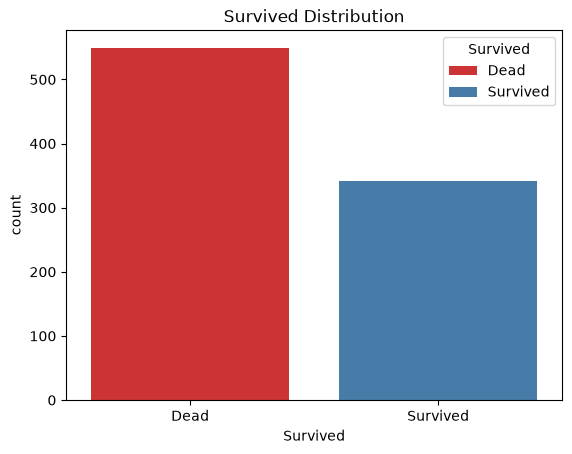

In [7]:
# The first chart shows that more passengers died than survived.
sns.countplot(x='Survived', data=training_data, hue='Survived', palette='Set1')
plt.title('Survived Distribution')
plt.xticks([0,1], ['Dead', 'Survived'])
plt.legend(title='Survived', labels=['Dead', 'Survived'])
plt.show()

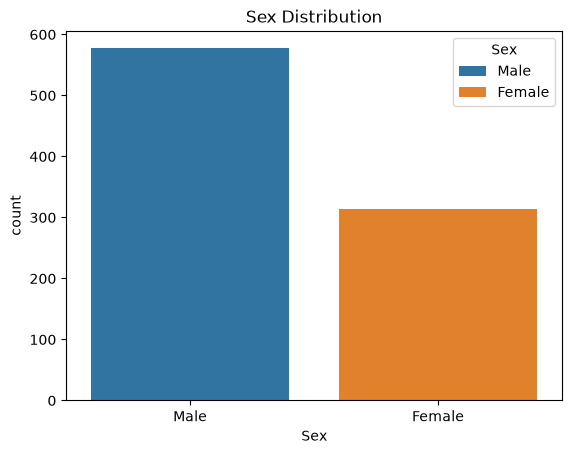

In [8]:
# The second chart shows that there were more male passengers than female passengers. 
sns.countplot(x='Sex', data=training_data, hue='Sex')
plt.title('Sex Distribution')
plt.xticks([0,1], ['Male', 'Female'])
plt.legend(title='Sex', labels=['Male', 'Female'])
plt.show()


# feature analysis

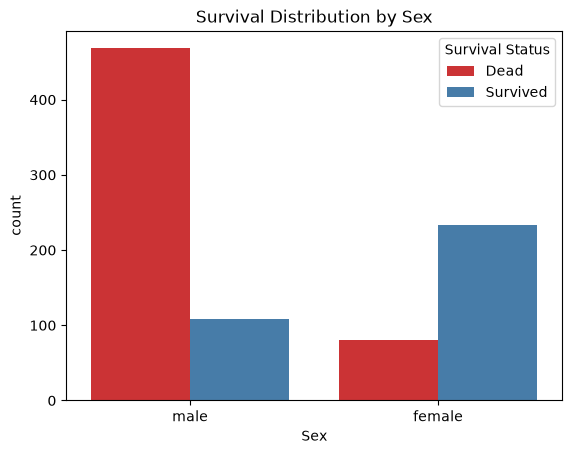

In [9]:
#The third chart shows that most men died, but many women survived.So,Sex is an important feature.
sns.countplot(x='Sex', data=training_data, hue='Survived', palette='Set1')
plt.title('Survival Distribution by Sex')
plt.legend(title='Survival Status', labels=['Dead', 'Survived'])
plt.show()

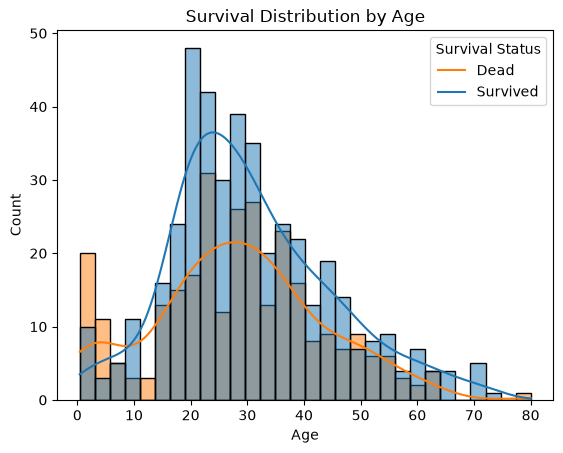

In [10]:
# The Age chart shows that most passengers were between 20 and 40 years old.
sns.histplot(x='Age', data=training_data, hue='Survived', bins=30, kde=True)
plt.title('Survival Distribution by Age')
plt.legend(title='Survival Status', labels=['Dead', 'Survived'])
plt.show()

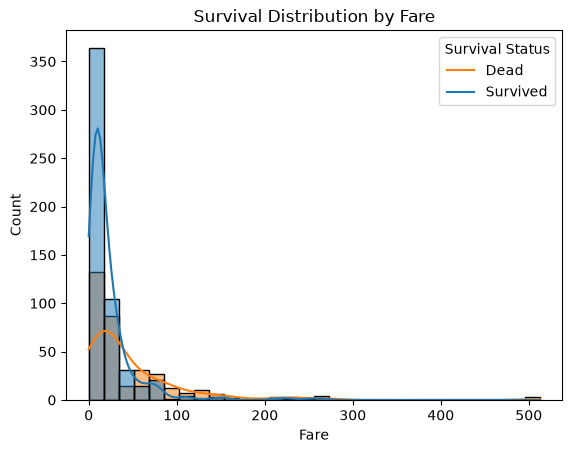

In [11]:
# The Fare chart shows that most passengers paid low fares, but passengers with higher fares had a better survival chance.
sns.histplot(x='Fare', data=training_data, hue='Survived', bins=30, kde=True)
plt.title('Survival Distribution by Fare')
plt.legend(title='Survival Status', labels=['Dead', 'Survived'])
plt.show()

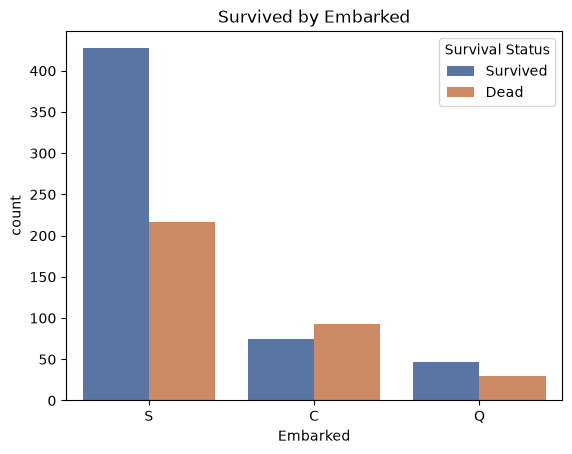

In [12]:
# Most passengers boarded from Southampton.Cherbourg passengers had the best survival rate.Queenstown had fewer passengers than Southampton.
sns.countplot(x='Embarked', data=training_data, hue='Survived', palette='deep')
plt.title('Survived by Embarked')
plt.legend(title='Survival Status', labels=['Survived', 'Dead'])
plt.show()

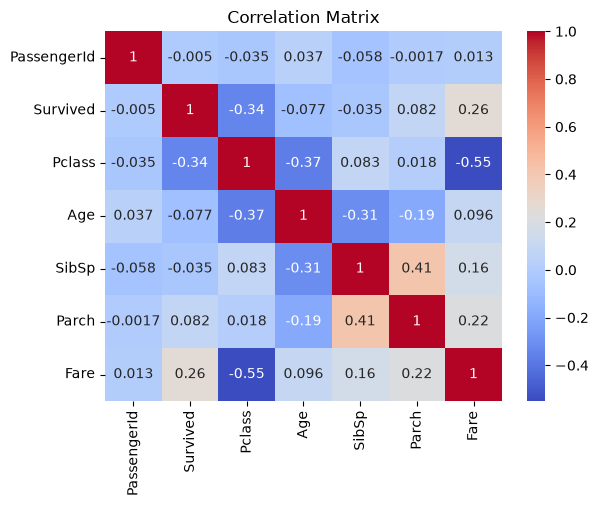

In [13]:
# correlation Matrix
correlation_matrix = training_data.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# data cleaning

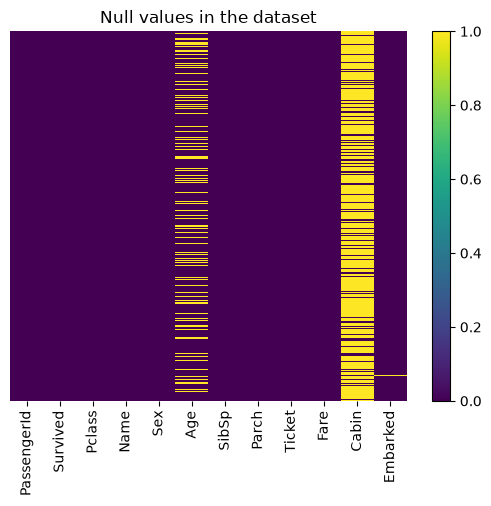

In [14]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()

In [15]:
# we drop the Cabin column because it has too many missing values
training_data = training_data.drop('Cabin', axis=1)
test_data = test_data.drop('Cabin', axis=1)

In [16]:
# for age column, we fill the missing values with the median of the age column
training_data['Age'] = training_data['Age'].fillna(training_data['Age'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())

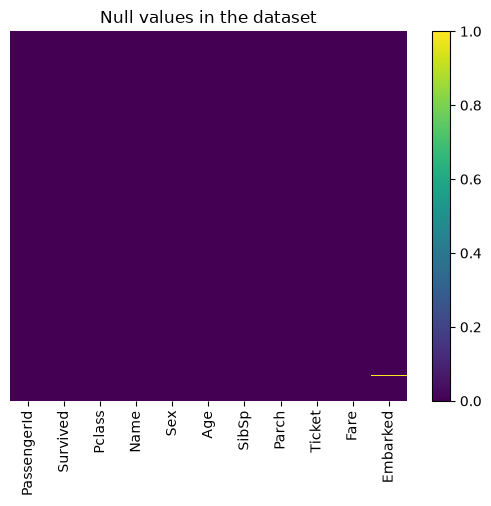

In [17]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()

In [18]:
# fill missing values in the embarked column with the mode of the embarked column
training_data['Embarked'] = training_data['Embarked'].fillna(training_data['Embarked'].mode()[0])
test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

In [19]:
training_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

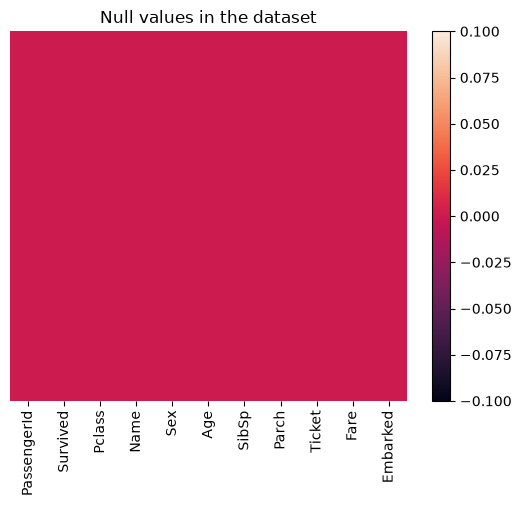

In [20]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False)
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()

## categorical to numerical transformation

In [21]:
# drop the Name, Ticket and PassengerId
training_data.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)
test_data.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)

In [22]:
# encode categorical features
training_data['Sex'] = training_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

In [23]:
# one-hot encoding to Embarked column
training_data = pd.get_dummies(training_data, columns=['Embarked'], drop_first=False, dtype=int)
test_data = pd.get_dummies(test_data, columns=['Embarked'], drop_first=False, dtype=int)
training_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


In [24]:
# training_data['Embarked_C'] = training_data['Embarked_C'].map({True: 1, False: 0})
# training_data['Embarked_Q'] = training_data['Embarked_Q'].map({True: 1, False: 0})
# training_data['Embarked_S'] = training_data['Embarked_S'].map({True: 1, False: 0})
# training_data.head()

In [25]:
# combining SibSp and Parch
training_data['FamilySize'] = training_data['SibSp'] + training_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
training_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,0,3,0,22.0,1,0,7.2500,0,0,1,2
1,1,1,1,38.0,1,0,71.2833,1,0,0,2
2,1,3,1,26.0,0,0,7.9250,0,0,1,1
3,1,1,1,35.0,1,0,53.1000,0,0,1,2
4,0,3,0,35.0,0,0,8.0500,0,0,1,1


In [26]:
# del SibSp and Parch column
training_data = training_data.drop(['SibSp', 'Parch'], axis=1)
test_data = test_data.drop(['SibSp', 'Parch'], axis=1)
training_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,0,3,0,22.0,7.2500,0,0,1,2
1,1,1,1,38.0,71.2833,1,0,0,2
2,1,3,1,26.0,7.9250,0,0,1,1
3,1,1,1,35.0,53.1000,0,0,1,2
4,0,3,0,35.0,8.0500,0,0,1,1


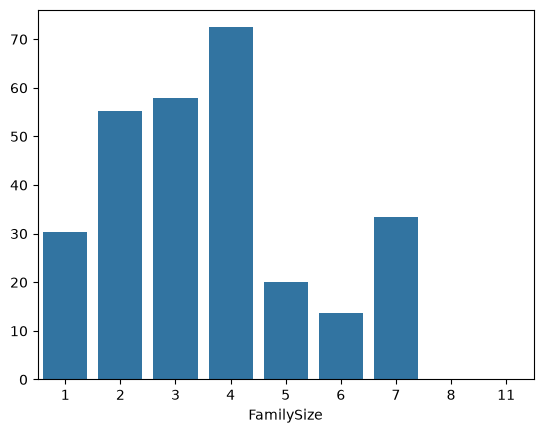

In [27]:
#The data is grouped by familly then the avrage srvival rate for each family group is calculated and *100 to get a percentage.
perce_survival = training_data.groupby('FamilySize')['Survived'].mean()*100 
sns.barplot(x=perce_survival.index, y=perce_survival.values)
plt.show()

## Train/ Validation split

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
training_features = training_data.drop(['Survived'], axis=1)
training_labels = training_data['Survived']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(training_features, training_labels, test_size=0.2)

In [31]:
print(f'X_train shape: {X_train.shape} - X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape} - y_test shape: {y_test.shape}')

X_train shape: (712, 8) - X_test shape: (179, 8)
y_train shape: (712,) - y_test shape: (179,)


# pre-processing

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluation_metrics(y_train, y_pred_train, y_test, y_pred_test):
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    print(f'Accuracy Train: {accuracy_train}')
    print(f'Accuracy Test: {accuracy_test}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1_Score:{f1}')

    print('\nConfusion_Matrix:')
    print(confusion_matrix(y_test, y_pred_test))
    
    print('\nClassification_Report:')
    print(classification_report(y_test, y_pred_test))
    
    return accuracy_train, accuracy_test, precision, recall, f1

## Model training

### 1.KNN

In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors= 17, weights='uniform', metric='euclidean')
knn.fit(X_train, y_train)
y_pred_train_knn = knn.predict(X_train)
y_pred_test_knn = knn.predict(X_test)

accuracy_train_knn, accuracy_test_knn, precision_knn, recall_knn, f1_knn = evaluation_metrics(y_train, y_pred_train_knn, y_test, y_pred_test_knn)

Accuracy Train: 0.8314606741573034
Accuracy Test: 0.7541899441340782
Precision: 0.6984126984126984
Recall: 0.6376811594202898
F1_Score:0.6666666666666666

Confusion_Matrix:
[[91 19]
 [25 44]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       110
           1       0.70      0.64      0.67        69

    accuracy                           0.75       179
   macro avg       0.74      0.73      0.74       179
weighted avg       0.75      0.75      0.75       179



### 2. GaussianNB

In [36]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_train_gnb = gnb.predict(X_train)
y_pred_test_gnb = gnb.predict(X_test)

accuracy_train_gnb, accuracy_test_gnb, precision_gnb, recall_gnb, f1_gnb = evaluation_metrics(y_train, y_pred_train_gnb, y_test, y_pred_test_gnb)

Accuracy Train: 0.8033707865168539
Accuracy Test: 0.7821229050279329
Precision: 0.7027027027027027
Recall: 0.7536231884057971
F1_Score:0.7272727272727273

Confusion_Matrix:
[[88 22]
 [17 52]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       110
           1       0.70      0.75      0.73        69

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.79      0.78      0.78       179



### 3. Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth= 5, min_samples_leaf=4, min_samples_split=10)
dt.fit(X_train, y_train)
y_pred_train_dt = dt.predict(X_train)
y_pred_test_dt = dt.predict(X_test)

accuracy_train_dt, accuracy_test_dt, precision_dt, recall_dt, f1_dt = evaluation_metrics(y_train, y_pred_train_dt, y_test, y_pred_test_dt)

Accuracy Train: 0.8567415730337079
Accuracy Test: 0.7541899441340782
Precision: 0.711864406779661
Recall: 0.6086956521739131
F1_Score:0.65625

Confusion_Matrix:
[[93 17]
 [27 42]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       110
           1       0.71      0.61      0.66        69

    accuracy                           0.75       179
   macro avg       0.74      0.73      0.73       179
weighted avg       0.75      0.75      0.75       179



### 4. Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, max_features='sqrt')
rf.fit(X_train, y_train)
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)

accuracy_train_rf, accuracy_test_rf, precision_rf, recall_rf, f1_rf = evaluation_metrics(y_train, y_pred_train_rf, y_test, y_pred_test_rf)

Accuracy Train: 0.8567415730337079
Accuracy Test: 0.7932960893854749
Precision: 0.8076923076923077
Recall: 0.6086956521739131
F1_Score:0.6942148760330579

Confusion_Matrix:
[[100  10]
 [ 27  42]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.84       110
           1       0.81      0.61      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



### 5. Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr = lr.predict(X_test)

accuracy_train_lr, accuracy_test_lr, precision_lr, recall_lr, f1_lr = evaluation_metrics(y_train, y_pred_train_lr, y_test, y_pred_test_lr)

Accuracy Train: 0.8146067415730337
Accuracy Test: 0.7430167597765364
Precision: 0.6716417910447762
Recall: 0.6521739130434783
F1_Score:0.6617647058823529

Confusion_Matrix:
[[88 22]
 [24 45]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79       110
           1       0.67      0.65      0.66        69

    accuracy                           0.74       179
   macro avg       0.73      0.73      0.73       179
weighted avg       0.74      0.74      0.74       179



### 6. SVM

In [40]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)
y_pred_train_svm = svm.predict(X_train)
y_pred_test_svm = svm.predict(X_test)

accuracy_train_svm, accuracy_test_svm, precision_svm, recall_svm, f1_svm = evaluation_metrics(y_train, y_pred_train_svm, y_test, y_pred_test_svm)

Accuracy Train: 0.8398876404494382
Accuracy Test: 0.7821229050279329
Precision: 0.75
Recall: 0.6521739130434783
F1_Score:0.6976744186046512

Confusion_Matrix:
[[95 15]
 [24 45]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       110
           1       0.75      0.65      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



### 7. ANN

In [41]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=50, max_iter=600, activation='relu', solver='adam')
mlp.fit(X_train, y_train)
y_pred_train_mlp = mlp.predict(X_train)
y_pred_test_mlp = mlp.predict(X_test)

accuracy_train_mlp, accuracy_test_mlp, precision_mlp, recall_mlp, f1_mlp = evaluation_metrics(y_train, y_pred_train_mlp, y_test, y_pred_test_mlp)

Accuracy Train: 0.848314606741573
Accuracy Test: 0.7932960893854749
Precision: 0.7758620689655172
Recall: 0.6521739130434783
F1_Score:0.7086614173228346

Confusion_Matrix:
[[97 13]
 [24 45]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



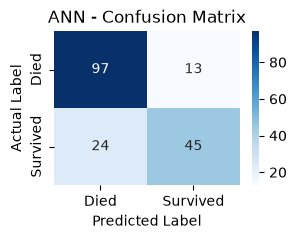

In [42]:
# ANN - confusion_matrix
cm = confusion_matrix(y_test, y_pred_test_mlp)
plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True, fmt ='d', cmap='Blues', xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('ANN - Confusion Matrix')
plt.show()

### Model Performance Comparison Table

In [43]:
results = pd.DataFrame({
    'Models': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'ANN'],
    'Accuracy Train': [accuracy_train_knn,accuracy_train_gnb,accuracy_train_dt,accuracy_train_rf,accuracy_train_lr,accuracy_train_svm,accuracy_train_mlp],
    'Accuracy Validation': [accuracy_test_knn,accuracy_test_gnb,accuracy_test_dt,accuracy_test_rf,accuracy_test_lr,accuracy_test_svm,accuracy_test_mlp],
    'Precision Validation': [precision_knn,precision_gnb,precision_dt,precision_rf,precision_lr,precision_svm,precision_mlp],
    'Recall Validation': [recall_knn,recall_gnb,recall_dt,recall_rf,recall_lr,recall_svm,recall_mlp],
    'F1 Score Validation': [f1_knn, f1_gnb, f1_dt, f1_rf, f1_lr, f1_svm, f1_mlp]
})
results

,Models,Accuracy Train,Accuracy Validation,Precision Validation,Recall Validation,F1 Score Validation
0,KNN,0.831461,0.754190,0.698413,0.637681,0.666667
1,GaussianNB,0.803371,0.782123,0.702703,0.753623,0.727273
2,Decision Tree,0.856742,0.754190,0.711864,0.608696,0.656250
3,Random Forest,0.856742,0.793296,0.807692,0.608696,0.694215
4,Logistic Regression,0.814607,0.743017,0.671642,0.652174,0.661765
5,SVM,0.839888,0.782123,0.750000,0.652174,0.697674
6,ANN,0.848315,0.793296,0.775862,0.652174,0.708661


### Accuracy (Train & Validation)

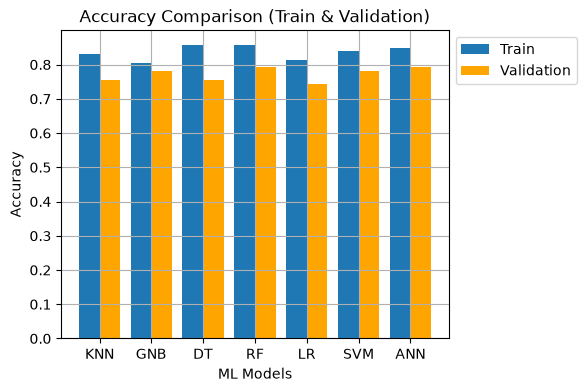

In [44]:
accuracy_train = [accuracy_train_knn,accuracy_train_gnb,accuracy_train_dt,accuracy_train_rf,accuracy_train_lr,accuracy_train_svm,accuracy_train_mlp]
accuracy_test = [accuracy_test_knn,accuracy_test_gnb,accuracy_test_dt,accuracy_test_rf,accuracy_test_lr,accuracy_test_svm,accuracy_test_mlp]
models = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(5,4))
x = np.arange(len(models))
plt.bar(x, accuracy_train, width=0.4, label='Train')
plt.bar(x + 0.4, accuracy_test, width=0.4, label='Validation', color='orange')
plt.xticks(x + 0.2, models)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.title('Accuracy Comparison (Train & Validation)')
plt.xlabel('ML Models')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

### Precision

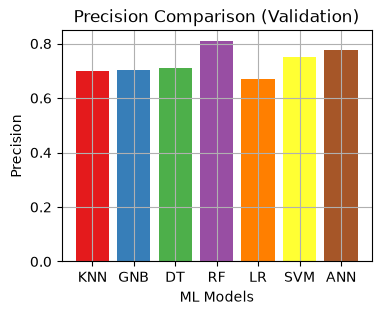

In [45]:
precision = [precision_knn, precision_gnb, precision_dt, precision_rf, precision_lr, precision_svm, precision_mlp]
models = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(4,3))
colors = plt.cm.Set1(range(len(models)))
plt.bar(models, precision, color=colors)
plt.title('Precision Comparison (Validation)')
plt.xlabel('ML Models')
plt.ylabel('Precision')
plt.grid()
plt.show()

### Recall

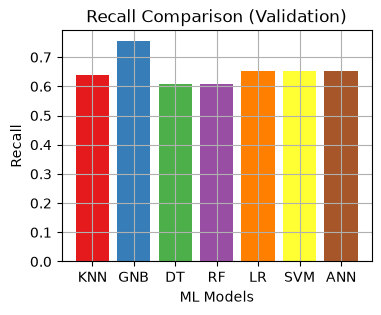

In [46]:
recall = [recall_knn, recall_gnb, recall_dt, recall_rf, recall_lr, recall_svm, recall_mlp]
models = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(4,3))
colors = plt.cm.Set1(range(len(models)))
plt.bar(models, recall, color=colors)
plt.title('Recall Comparison (Validation)')
plt.xlabel('ML Models')
plt.ylabel('Recall')
plt.grid()
plt.show()

### F1-Score

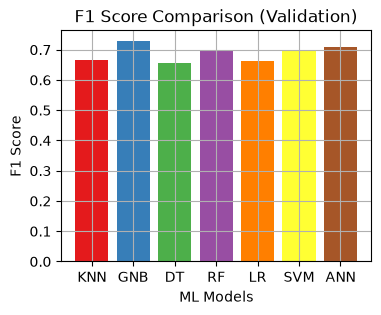

In [47]:
f1 = [f1_knn, f1_gnb, f1_dt, f1_rf, f1_lr, f1_svm, f1_mlp]
models = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(4,3))
colors = plt.cm.Set1(range(len(models)))
plt.bar(models, f1, color=colors)
plt.title('F1 Score Comparison (Validation)')
plt.xlabel('ML Models')
plt.ylabel('F1 Score')
plt.grid()
plt.show()

## Dimensionality Reduction

### PCA (Principal Component Analysis)

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [49]:
print(f'X_train shape: {X_train.shape} - X_test shape(PCA): {X_test_pca.shape}')

X_train shape: (712, 8) - X_test shape(PCA): (179, 5)


### 1.KNN-PCA

In [50]:
knn = KNeighborsClassifier(n_neighbors= 17, weights='uniform', metric='euclidean')
knn.fit(X_train_pca, y_train)

y_pred_train_knn_pca = knn.predict(X_train_pca)
y_pred_test_knn_pca = knn.predict(X_test_pca)

accuracy_train_knn_pca, accuracy_test_knn_pca, precision_knn_pca, recall_knn_pca, f1_knn_pca = evaluation_metrics(y_train, y_pred_train_knn_pca, y_test, y_pred_test_knn_pca)

Accuracy Train: 0.8146067415730337
Accuracy Test: 0.7653631284916201
Precision: 0.7213114754098361
Recall: 0.6376811594202898
F1_Score:0.676923076923077

Confusion_Matrix:
[[93 17]
 [25 44]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       110
           1       0.72      0.64      0.68        69

    accuracy                           0.77       179
   macro avg       0.75      0.74      0.75       179
weighted avg       0.76      0.77      0.76       179



### 2. GaussianNB-PCA

In [51]:
gnb = GaussianNB()
gnb.fit(X_train_pca, y_train)

y_pred_train_gnb_pca = gnb.predict(X_train_pca)
y_pred_test_gnb_pca = gnb.predict(X_test_pca)

accuracy_train_gnb_pca, accuracy_test_gnb_pca, precision_gnb_pca, recall_gnb_pca, f1_gnb_pca = evaluation_metrics(y_train, y_pred_train_gnb_pca, y_test, y_pred_test_gnb_pca)

Accuracy Train: 0.8033707865168539
Accuracy Test: 0.770949720670391
Precision: 0.7121212121212122
Recall: 0.6811594202898551
F1_Score:0.6962962962962963

Confusion_Matrix:
[[91 19]
 [22 47]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.71      0.68      0.70        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.76       179
weighted avg       0.77      0.77      0.77       179



### 3. Decision Tree-PCA

In [52]:
dt = DecisionTreeClassifier(max_depth= 5, min_samples_leaf=4, min_samples_split=10)
dt.fit(X_train_pca, y_train)
y_pred_train_dt_pca = dt.predict(X_train_pca)
y_pred_test_dt_pca = dt.predict(X_test_pca)

accuracy_train_dt_pca, accuracy_test_dt_pca, precision_dt_pca, recall_dt_pca, f1_dt_pca = evaluation_metrics(y_train, y_pred_train_dt_pca, y_test, y_pred_test_dt_pca)

Accuracy Train: 0.8623595505617978
Accuracy Test: 0.7653631284916201
Precision: 0.7014925373134329
Recall: 0.6811594202898551
F1_Score:0.6911764705882353

Confusion_Matrix:
[[90 20]
 [22 47]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       110
           1       0.70      0.68      0.69        69

    accuracy                           0.77       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



### 4. Random Forest-PCA

In [53]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, max_features='sqrt')
rf.fit(X_train_pca, y_train)
y_pred_train_rf_pca = rf.predict(X_train_pca)
y_pred_test_rf_pca = rf.predict(X_test_pca)

accuracy_train_rf_pca, accuracy_test_rf_pca, precision_rf_pca, recall_rf_pca, f1_rf_pca = evaluation_metrics(y_train, y_pred_train_rf_pca, y_test, y_pred_test_rf_pca)

Accuracy Train: 0.8834269662921348
Accuracy Test: 0.776536312849162
Precision: 0.7457627118644068
Recall: 0.6376811594202898
F1_Score:0.6875

Confusion_Matrix:
[[95 15]
 [25 44]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.83       110
           1       0.75      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179



### 5.Logestic Regression-PCA

In [54]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_pca, y_train)

y_pred_train_lr_pca = lr.predict(X_train_pca)
y_pred_test_lr_pca = lr.predict(X_test_pca)

accuracy_train_lr_pca, accuracy_test_lr_pca, precision_lr_pca, recall_lr_pca, f1_lr_pca = evaluation_metrics(y_train, y_pred_train_lr_pca, y_test, y_pred_test_lr_pca)

Accuracy Train: 0.7963483146067416
Accuracy Test: 0.7430167597765364
Precision: 0.6716417910447762
Recall: 0.6521739130434783
F1_Score:0.6617647058823529

Confusion_Matrix:
[[88 22]
 [24 45]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79       110
           1       0.67      0.65      0.66        69

    accuracy                           0.74       179
   macro avg       0.73      0.73      0.73       179
weighted avg       0.74      0.74      0.74       179



### 6. SVM-PCA

In [55]:
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_pca, y_train)
y_pred_train_svm_pca = svm.predict(X_train_pca)
y_pred_test_svm_pca = svm.predict(X_test_pca)

accuracy_train_svm_pca, accuracy_test_svm_pca, precision_svm_pca, recall_svm_pca, f1_svm_pca = evaluation_metrics(y_train, y_pred_train_svm_pca, y_test, y_pred_test_svm_pca)

Accuracy Train: 0.8160112359550562
Accuracy Test: 0.7597765363128491
Precision: 0.703125
Recall: 0.6521739130434783
F1_Score:0.6766917293233082

Confusion_Matrix:
[[91 19]
 [24 45]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       110
           1       0.70      0.65      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



### 7. ANN-PCA

In [56]:
mlp = MLPClassifier(hidden_layer_sizes=50, max_iter=600, activation='relu', solver='adam')
mlp.fit(X_train_pca, y_train)
y_pred_train_mlp_pca = mlp.predict(X_train_pca)
y_pred_test_mlp_pca = mlp.predict(X_test_pca)

accuracy_train_mlp_pca, accuracy_test_mlp_pca, precision_mlp_pca, recall_mlp_pca, f1_mlp_pca = evaluation_metrics(y_train, y_pred_train_mlp_pca, y_test, y_pred_test_mlp_pca)

Accuracy Train: 0.8412921348314607
Accuracy Test: 0.7653631284916201
Precision: 0.7142857142857143
Recall: 0.6521739130434783
F1_Score:0.6818181818181818

Confusion_Matrix:
[[92 18]
 [24 45]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       110
           1       0.71      0.65      0.68        69

    accuracy                           0.77       179
   macro avg       0.75      0.74      0.75       179
weighted avg       0.76      0.77      0.76       179



### Model Performance Comparison Table - PCA

In [57]:
results_pca = pd.DataFrame({
    'Models PCA': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'ANN'],
    'Accuracy Train PCA': [accuracy_train_knn_pca,accuracy_train_gnb_pca,accuracy_train_dt_pca,accuracy_train_rf_pca,accuracy_train_lr_pca,accuracy_train_svm_pca,accuracy_train_mlp_pca],
    'Accuracy Validation PCA': [accuracy_test_knn_pca,accuracy_test_gnb_pca,accuracy_test_dt_pca,accuracy_test_rf_pca,accuracy_test_lr_pca,accuracy_test_svm_pca,accuracy_test_mlp_pca],
    'Precision Validation PCA': [precision_knn_pca,precision_gnb_pca,precision_dt_pca,precision_rf_pca,precision_lr_pca,precision_svm_pca,precision_mlp_pca],
    'Recall Validation PCA': [recall_knn_pca,recall_gnb_pca,recall_dt_pca,recall_rf_pca,recall_lr_pca,recall_svm_pca,recall_mlp_pca],
    'F1 Score Validation PCA': [f1_knn_pca, f1_gnb_pca, f1_dt_pca, f1_rf_pca, f1_lr_pca, f1_svm_pca, f1_mlp_pca]
})
results_pca

,Models PCA,Accuracy Train PCA,Accuracy Validation PCA,Precision Validation PCA,Recall Validation PCA,F1 Score Validation PCA
0,KNN,0.814607,0.765363,0.721311,0.637681,0.676923
1,GaussianNB,0.803371,0.770950,0.712121,0.681159,0.696296
2,Decision Tree,0.862360,0.765363,0.701493,0.681159,0.691176
3,Random Forest,0.883427,0.776536,0.745763,0.637681,0.687500
4,Logistic Regression,0.796348,0.743017,0.671642,0.652174,0.661765
5,SVM,0.816011,0.759777,0.703125,0.652174,0.676692
6,ANN,0.841292,0.765363,0.714286,0.652174,0.681818


### Accuracy(Train & Validation) - PCA

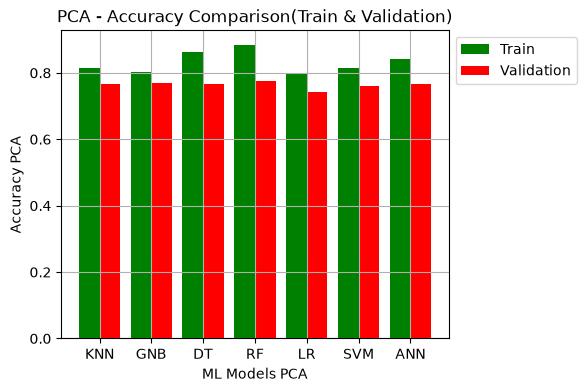

In [58]:
accuracy_train_pca = [accuracy_train_knn_pca,accuracy_train_gnb_pca,accuracy_train_dt_pca,accuracy_train_rf_pca,accuracy_train_lr_pca,accuracy_train_svm_pca,accuracy_train_mlp_pca]
accuracy_test_pca = [accuracy_test_knn_pca,accuracy_test_gnb_pca,accuracy_test_dt_pca,accuracy_test_rf_pca,accuracy_test_lr_pca,accuracy_test_svm_pca,accuracy_test_mlp_pca]
models_pca = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(5,4))
x = np.arange(len(models_pca))
plt.bar(x, accuracy_train_pca, width=0.4, label='Train', color='green')
plt.bar(x + 0.4, accuracy_test_pca, width=0.4, label='Validation', color='red')
plt.xticks(x + 0.2, models_pca)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.title('PCA - Accuracy Comparison(Train & Validation)')
plt.xlabel('ML Models PCA')
plt.ylabel('Accuracy PCA')
plt.grid()
plt.show()

### Precision - PCA

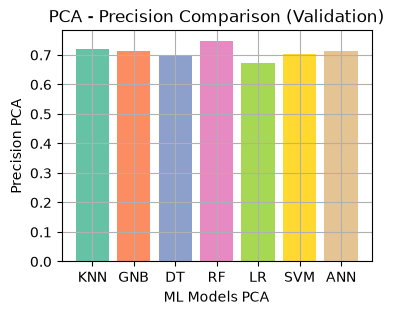

In [59]:
precision_pca = [precision_knn_pca,precision_gnb_pca,precision_dt_pca,precision_rf_pca,precision_lr_pca,precision_svm_pca,precision_mlp_pca]
models_pca = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(4,3))
colors = plt.cm.Set2(range(len(models_pca)))
plt.bar(models_pca, precision_pca, color=colors)
plt.title('PCA - Precision Comparison (Validation)')
plt.xlabel('ML Models PCA')
plt.ylabel('Precision PCA')
plt.grid()
plt.show()

### Recall - PCA

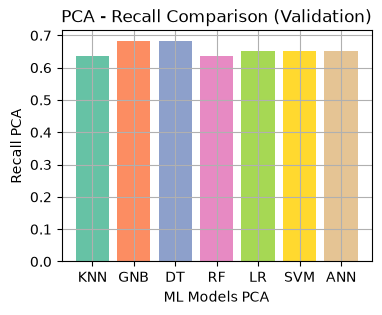

In [60]:
recall_pca = [recall_knn_pca,recall_gnb_pca,recall_dt_pca,recall_rf_pca,recall_lr_pca,recall_svm_pca,recall_mlp_pca]
models_pca = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(4,3))
colors = plt.cm.Set2(range(len(models_pca)))
plt.bar(models_pca, recall_pca, color=colors)
plt.title('PCA - Recall Comparison (Validation)')
plt.xlabel('ML Models PCA')
plt.ylabel('Recall PCA')
plt.grid()
plt.show()

### F1 Score - PCA

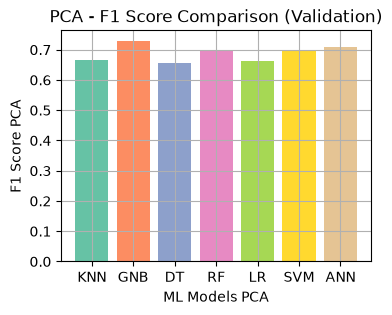

In [61]:
f1_pca = [f1_knn, f1_gnb, f1_dt, f1_rf, f1_lr, f1_svm, f1_mlp]
models_pca = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(4,3))
colors = plt.cm.Set2(range(len(models_pca)))
plt.bar(models_pca, f1_pca, color=colors)
plt.title('PCA - F1 Score Comparison (Validation)')
plt.xlabel('ML Models PCA')
plt.ylabel('F1 Score PCA')
plt.grid()
plt.show()

## SVD (Singular Value Decomposition)

In [62]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=5)

X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

In [63]:
print(f'X_train shape: {X_train.shape} - X_test shape(SVD): {X_test_svd.shape}')

X_train shape: (712, 8) - X_test shape(SVD): (179, 5)


### 1. KNN-SVD

In [64]:
knn = KNeighborsClassifier(n_neighbors= 17, weights='uniform', metric='euclidean')
knn.fit(X_train_svd, y_train)

y_pred_train_knn_svd = knn.predict(X_train_svd)
y_pred_test_knn_svd = knn.predict(X_test_svd)

accuracy_train_knn_svd, accuracy_test_knn_svd, precision_knn_svd, recall_knn_svd, f1_knn_svd = evaluation_metrics(y_train, y_pred_train_knn_svd, y_test, y_pred_test_knn_svd)

Accuracy Train: 0.8146067415730337
Accuracy Test: 0.7653631284916201
Precision: 0.7213114754098361
Recall: 0.6376811594202898
F1_Score:0.676923076923077

Confusion_Matrix:
[[93 17]
 [25 44]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       110
           1       0.72      0.64      0.68        69

    accuracy                           0.77       179
   macro avg       0.75      0.74      0.75       179
weighted avg       0.76      0.77      0.76       179



### 2. GaussianNB-SVD

In [65]:
gnb = GaussianNB()
gnb.fit(X_train_svd, y_train)

y_pred_train_gnb_svd = gnb.predict(X_train_svd)
y_pred_test_gnb_svd = gnb.predict(X_test_svd)

accuracy_train_gnb_svd, accuracy_test_gnb_svd, precision_gnb_svd, recall_gnb_svd, f1_gnb_svd = evaluation_metrics(y_train, y_pred_train_gnb_svd, y_test, y_pred_test_gnb_svd)

Accuracy Train: 0.8033707865168539
Accuracy Test: 0.770949720670391
Precision: 0.7121212121212122
Recall: 0.6811594202898551
F1_Score:0.6962962962962963

Confusion_Matrix:
[[91 19]
 [22 47]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.71      0.68      0.70        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.76       179
weighted avg       0.77      0.77      0.77       179



### 3. Decision Tree-SVD

In [66]:
dt = DecisionTreeClassifier(max_depth= 5, min_samples_leaf=4, min_samples_split=10)
dt.fit(X_train_svd, y_train)

y_pred_train_dt_svd = dt.predict(X_train_svd)
y_pred_test_dt_svd = dt.predict(X_test_svd)

accuracy_train_dt_svd, accuracy_test_dt_svd, precision_dt_svd, recall_dt_svd, f1_dt_svd = evaluation_metrics(y_train, y_pred_train_dt_svd, y_test, y_pred_test_dt_svd)

Accuracy Train: 0.8623595505617978
Accuracy Test: 0.7653631284916201
Precision: 0.7014925373134329
Recall: 0.6811594202898551
F1_Score:0.6911764705882353

Confusion_Matrix:
[[90 20]
 [22 47]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       110
           1       0.70      0.68      0.69        69

    accuracy                           0.77       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



### 4. Random Forest-SVD

In [67]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, max_features='sqrt')
rf.fit(X_train_svd, y_train)
y_pred_train_rf_svd = rf.predict(X_train_svd)
y_pred_test_rf_svd = rf.predict(X_test_svd)

accuracy_train_rf_svd, accuracy_test_rf_svd, precision_rf_svd, recall_rf_svd, f1_rf_svd = evaluation_metrics(y_train, y_pred_train_rf_svd, y_test, y_pred_test_rf_svd)

Accuracy Train: 0.8820224719101124
Accuracy Test: 0.770949720670391
Precision: 0.7333333333333333
Recall: 0.6376811594202898
F1_Score:0.6821705426356589

Confusion_Matrix:
[[94 16]
 [25 44]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       110
           1       0.73      0.64      0.68        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



### 5.Logestic Regression-SVD

In [68]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_svd, y_train)

y_pred_train_lr_svd = lr.predict(X_train_svd)
y_pred_test_lr_svd = lr.predict(X_test_svd)

accuracy_train_lr_svd, accuracy_test_lr_svd, precision_lr_svd, recall_lr_svd, f1_lr_svd = evaluation_metrics(y_train, y_pred_train_lr_svd, y_test, y_pred_test_lr_svd)

Accuracy Train: 0.7963483146067416
Accuracy Test: 0.7430167597765364
Precision: 0.6716417910447762
Recall: 0.6521739130434783
F1_Score:0.6617647058823529

Confusion_Matrix:
[[88 22]
 [24 45]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79       110
           1       0.67      0.65      0.66        69

    accuracy                           0.74       179
   macro avg       0.73      0.73      0.73       179
weighted avg       0.74      0.74      0.74       179



### 6. SVM-SVD

In [69]:
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_svd, y_train)
y_pred_train_svm_svd = svm.predict(X_train_svd)
y_pred_test_svm_svd = svm.predict(X_test_svd)

accuracy_train_svm_svd, accuracy_test_svm_svd, precision_svm_svd, recall_svm_svd, f1_svm_svd = evaluation_metrics(y_train, y_pred_train_svm_svd, y_test, y_pred_test_svm_svd)

Accuracy Train: 0.8160112359550562
Accuracy Test: 0.7597765363128491
Precision: 0.703125
Recall: 0.6521739130434783
F1_Score:0.6766917293233082

Confusion_Matrix:
[[91 19]
 [24 45]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       110
           1       0.70      0.65      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



### 7. ANN-SVD

In [70]:
mlp = MLPClassifier(hidden_layer_sizes=50, max_iter=600, activation='relu', solver='adam')
mlp.fit(X_train_svd, y_train)
y_pred_train_mlp_svd = mlp.predict(X_train_svd)
y_pred_test_mlp_svd = mlp.predict(X_test_svd)

accuracy_train_mlp_svd, accuracy_test_mlp_svd, precision_mlp_svd, recall_mlp_svd, f1_mlp_svd = evaluation_metrics(y_train, y_pred_train_mlp_svd, y_test, y_pred_test_mlp_svd)

Accuracy Train: 0.8314606741573034
Accuracy Test: 0.7597765363128491
Precision: 0.703125
Recall: 0.6521739130434783
F1_Score:0.6766917293233082

Confusion_Matrix:
[[91 19]
 [24 45]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       110
           1       0.70      0.65      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



### Model Performance Comparison Table - SVD

In [71]:
results_svd = pd.DataFrame({
    'Models SVD': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'ANN'],
    'Accuracy Train SVD': [accuracy_train_knn_svd,accuracy_train_gnb_svd,accuracy_train_dt_svd,accuracy_train_rf_svd,accuracy_train_lr_svd,accuracy_train_svm_svd,accuracy_train_mlp_svd],
    'Accuracy Validation SVD': [accuracy_test_knn_svd,accuracy_test_gnb_svd,accuracy_test_dt_svd,accuracy_test_rf_svd,accuracy_test_lr_svd,accuracy_test_svm_svd,accuracy_test_mlp_svd],
    'Precision Validation SVD': [precision_knn_svd,precision_gnb_svd,precision_dt_svd,precision_rf_svd,precision_lr_svd,precision_svm_svd,precision_mlp_svd],
    'Recall Validation SVD': [recall_knn_svd,recall_gnb_svd,recall_dt_svd,recall_rf_svd,recall_lr_svd,recall_svm_svd,recall_mlp_svd],
    'F1 Score Validation SVD': [f1_knn_svd, f1_gnb_svd, f1_dt_svd, f1_rf_svd, f1_lr_svd, f1_svm_svd, f1_mlp_svd]
})
results_svd

,Models SVD,Accuracy Train SVD,Accuracy Validation SVD,Precision Validation SVD,Recall Validation SVD,F1 Score Validation SVD
0,KNN,0.814607,0.765363,0.721311,0.637681,0.676923
1,GaussianNB,0.803371,0.770950,0.712121,0.681159,0.696296
2,Decision Tree,0.862360,0.765363,0.701493,0.681159,0.691176
3,Random Forest,0.882022,0.770950,0.733333,0.637681,0.682171
4,Logistic Regression,0.796348,0.743017,0.671642,0.652174,0.661765
5,SVM,0.816011,0.759777,0.703125,0.652174,0.676692
6,ANN,0.831461,0.759777,0.703125,0.652174,0.676692


### Accuracy(Train & Validation) - SVD

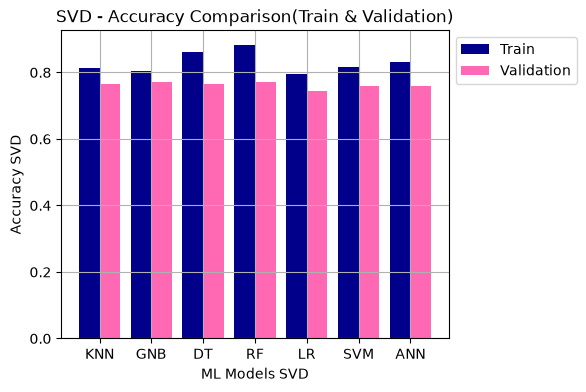

In [72]:
accuracy_train_svd = [accuracy_train_knn_svd,accuracy_train_gnb_svd,accuracy_train_dt_svd,accuracy_train_rf_svd,accuracy_train_lr_svd,accuracy_train_svm_svd,accuracy_train_mlp_svd]
accuracy_test_svd = [accuracy_test_knn_svd,accuracy_test_gnb_svd,accuracy_test_dt_svd,accuracy_test_rf_svd,accuracy_test_lr_svd,accuracy_test_svm_svd,accuracy_test_mlp_svd]
models_svd = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(5,4))
x = np.arange(len(models_svd))
plt.bar(x, accuracy_train_svd, width=0.4, label='Train', color='darkblue' )
plt.bar(x + 0.4, accuracy_test_svd, width=0.4, label='Validation', color='hotpink')
plt.xticks(x + 0.2, models_svd)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.title('SVD - Accuracy Comparison(Train & Validation)')
plt.xlabel('ML Models SVD')
plt.ylabel('Accuracy SVD')
plt.grid()
plt.show()

### Precision - SVD

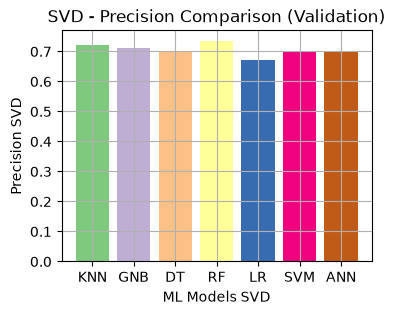

In [73]:
precision_svd = [precision_knn_svd,precision_gnb_svd,precision_dt_svd,precision_rf_svd,precision_lr_svd,precision_svm_svd,precision_mlp_svd]
models_svd = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(4,3))
colors = plt.cm.Accent(range(len(models_svd)))
plt.bar(models_svd, precision_svd, color=colors)
plt.title('SVD - Precision Comparison (Validation)')
plt.xlabel('ML Models SVD')
plt.ylabel('Precision SVD')
plt.grid()
plt.show()

### Recall - SVD

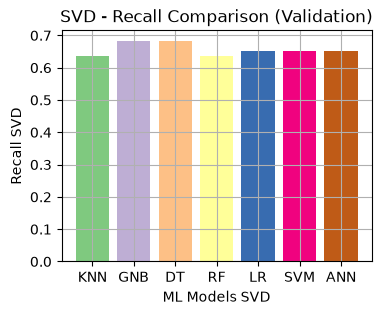

In [74]:
recall_svd = [recall_knn_svd,recall_gnb_svd,recall_dt_svd,recall_rf_svd,recall_lr_svd,recall_svm_svd,recall_mlp_svd]
models_svd = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(4,3))
colors = plt.cm.Accent(range(len(models_svd)))
plt.bar(models_svd, recall_svd, color=colors)
plt.title('SVD - Recall Comparison (Validation)')
plt.xlabel('ML Models SVD')
plt.ylabel('Recall SVD')
plt.grid()
plt.show()

### F1 Score - SVD

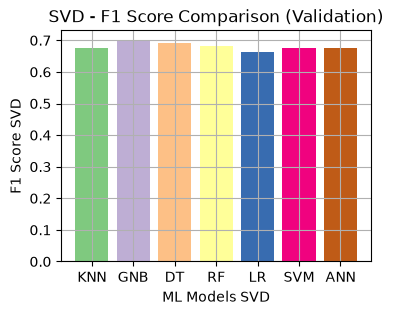

In [75]:
f1_svd = [f1_knn_svd, f1_gnb_svd, f1_dt_svd, f1_rf_svd, f1_lr_svd, f1_svm_svd, f1_mlp_svd]
models_svd = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
plt.figure(figsize=(4,3))
colors = plt.cm.Accent(range(len(models_svd)))
plt.bar(models_svd, f1_svd, color=colors)
plt.title('SVD - F1 Score Comparison (Validation)')
plt.xlabel('ML Models SVD')
plt.ylabel('F1 Score SVD')
plt.grid()
plt.show()

### Accuracy Comparison Table (Original - PCA - SVD)

In [76]:
comparison_accuracy = pd.DataFrame({
    'Models': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'ANN'],
    'Accuracy Train': [accuracy_train_knn,accuracy_train_gnb,accuracy_train_dt,accuracy_train_rf,accuracy_train_lr,accuracy_train_svm,accuracy_train_mlp],
    'Accuracy Train PCA': [accuracy_train_knn_pca,accuracy_train_gnb_pca,accuracy_train_dt_pca,accuracy_train_rf_pca,accuracy_train_lr_pca,accuracy_train_svm_pca,accuracy_train_mlp_pca],
    'Accuracy Train SVD': [accuracy_train_knn_svd,accuracy_train_gnb_svd,accuracy_train_dt_svd,accuracy_train_rf_svd,accuracy_train_lr_svd,accuracy_train_svm_svd,accuracy_train_mlp_svd],
    'Accuracy Validation': [accuracy_test_knn,accuracy_test_gnb,accuracy_test_dt,accuracy_test_rf,accuracy_test_lr,accuracy_test_svm,accuracy_test_mlp],
    'Accuracy Validation PCA': [accuracy_test_knn_pca,accuracy_test_gnb_pca,accuracy_test_dt_pca,accuracy_test_rf_pca,accuracy_test_lr_pca,accuracy_test_svm_pca,accuracy_test_mlp_pca],
    'Accuracy Validation SVD': [accuracy_test_knn_svd,accuracy_test_gnb_svd,accuracy_test_dt_svd,accuracy_test_rf_svd,accuracy_test_lr_svd,accuracy_test_svm_svd,accuracy_test_mlp_svd],
})
comparison_accuracy

,Models,Accuracy Train,Accuracy Train PCA,Accuracy Train SVD,Accuracy Validation,Accuracy Validation PCA,Accuracy Validation SVD
0,KNN,0.831461,0.814607,0.814607,0.754190,0.765363,0.765363
1,GaussianNB,0.803371,0.803371,0.803371,0.782123,0.770950,0.770950
2,Decision Tree,0.856742,0.862360,0.862360,0.754190,0.765363,0.765363
3,Random Forest,0.856742,0.883427,0.882022,0.793296,0.776536,0.770950
4,Logistic Regression,0.814607,0.796348,0.796348,0.743017,0.743017,0.743017
5,SVM,0.839888,0.816011,0.816011,0.782123,0.759777,0.759777
6,ANN,0.848315,0.841292,0.831461,0.793296,0.765363,0.759777


### Accuracy (Original - PCA - SVD) 

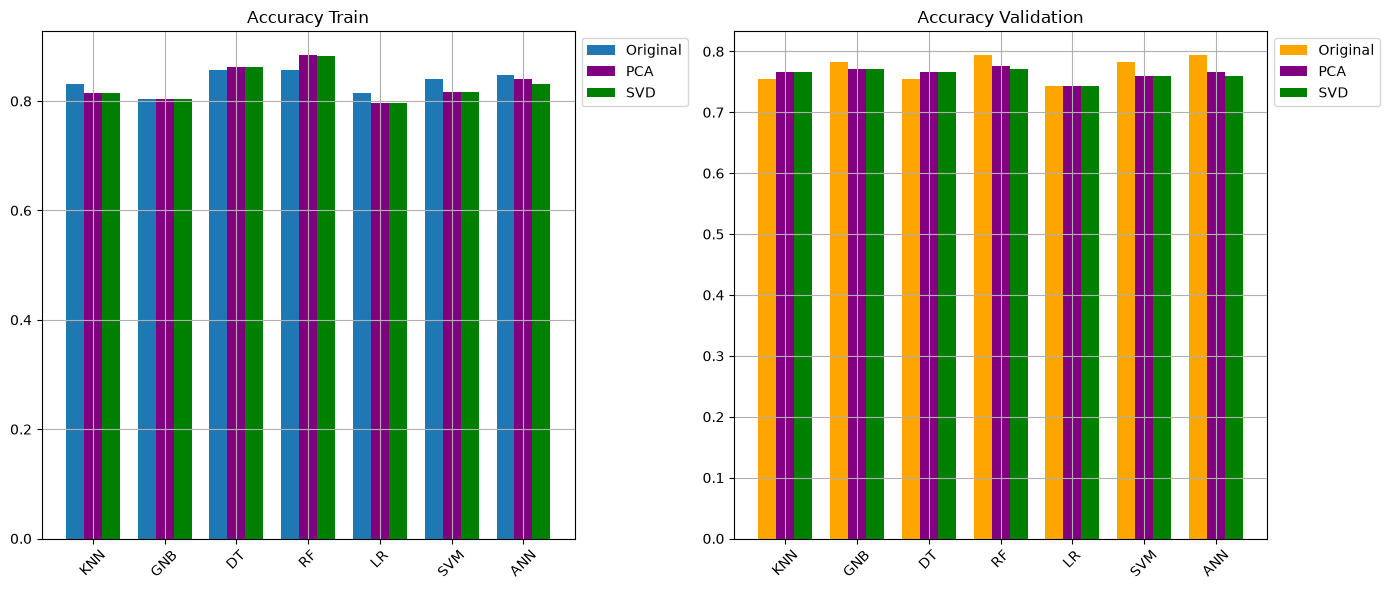

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = [None, 'orange']
metrics = [
   ('Accuracy Train', 'Accuracy Train PCA', 'Accuracy Train SVD', 'Accuracy Train'),
   ('Accuracy Validation', 'Accuracy Validation PCA', 'Accuracy Validation SVD', 'Accuracy Validation'),
]
for i, (col, col_pca, col_svd, title) in enumerate(metrics):
   x = np.arange(len(models))
   axes[i].bar(x, comparison_accuracy[col], width=0.25, label='Original', color=colors[i])
   axes[i].bar(x + 0.25, comparison_accuracy[col_pca], width=0.25, label='PCA', color='purple')
   axes[i].bar(x + 0.5, comparison_accuracy[col_svd], width=0.25, label='SVD', color='green')
   axes[i].set_xticks(x + 0.25)
   axes[i].set_xticklabels(models, rotation=45)
   axes[i].set_title(title)
   axes[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
   axes[i].grid()
plt.tight_layout()
plt.show()

### Precision (Original - PCA - SVD)

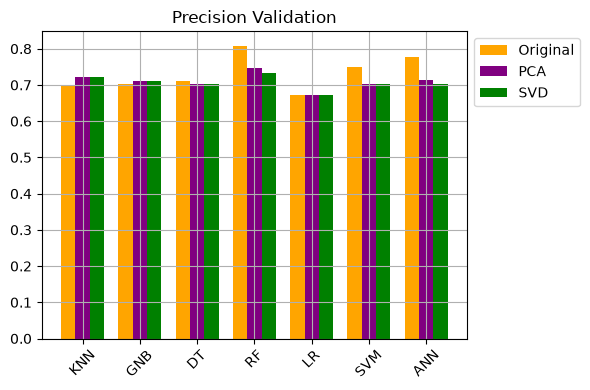

In [78]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
x = np.arange(len(models))

precision_original = [precision_knn,precision_gnb,precision_dt,precision_rf,precision_lr,precision_svm,precision_mlp]
precision_pca = [precision_knn_pca,precision_gnb_pca,precision_dt_pca,precision_rf_pca,precision_lr_pca,precision_svm_pca,precision_mlp_pca]
precision_svd = [precision_knn_svd,precision_gnb_svd,precision_dt_svd,precision_rf_svd,precision_lr_svd,precision_svm_svd,precision_mlp_svd]

axes.bar(x, precision_original, width=0.25, label='Original', color='orange')
axes.bar(x + 0.25, precision_pca, width=0.25, label='PCA', color='purple')
axes.bar(x + 0.5, precision_svd, width=0.25, label='SVD', color='green')
axes.set_xticks(x + 0.25)
axes.set_xticklabels(models, rotation=45)
axes.set_title('Precision Validation')
axes.legend(loc='upper left', bbox_to_anchor=(1, 1))
axes.grid()
plt.tight_layout()
plt.show()

### Recall (Original - PCA - SVD)

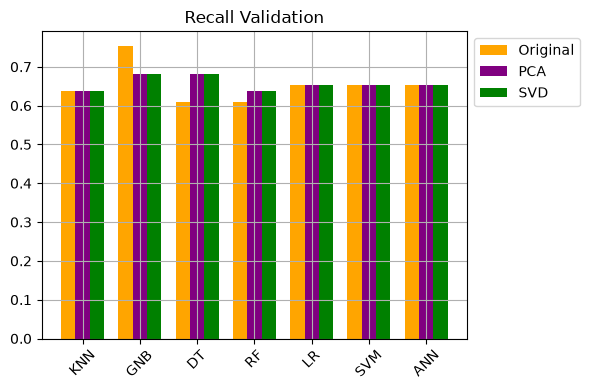

In [79]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
x = np.arange(len(models))

recall_original = [recall_knn,recall_gnb,recall_dt,recall_rf,recall_lr,recall_svm,recall_mlp]
recall_pca = [recall_knn_pca,recall_gnb_pca,recall_dt_pca,recall_rf_pca,recall_lr_pca,recall_svm_pca,recall_mlp_pca]
recall_svd = [recall_knn_svd,recall_gnb_svd,recall_dt_svd,recall_rf_svd,recall_lr_svd,recall_svm_svd,recall_mlp_svd]

axes.bar(x, recall_original, width=0.25, label='Original', color='orange')
axes.bar(x + 0.25, recall_pca, width=0.25, label='PCA', color='purple')
axes.bar(x + 0.5, recall_svd, width=0.25, label='SVD', color='green')
axes.set_xticks(x + 0.25)
axes.set_xticklabels(models, rotation=45)
axes.set_title('Recall Validation')
axes.legend(loc='upper left', bbox_to_anchor=(1, 1))
axes.grid()
plt.tight_layout()
plt.show()

### F1 Score (Original - PCA - SVD)

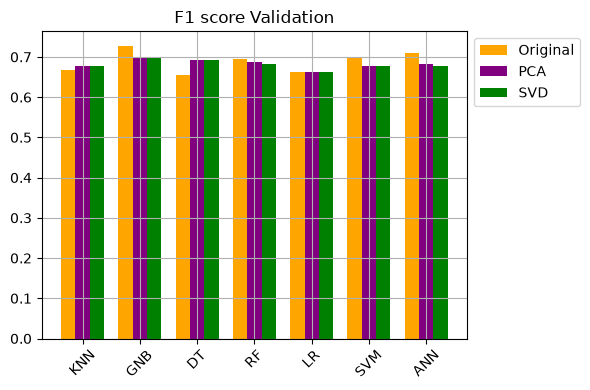

In [80]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
x = np.arange(len(models))

f1_original = [f1_knn, f1_gnb, f1_dt, f1_rf, f1_lr, f1_svm, f1_mlp]
f1_pca = [f1_knn_pca, f1_gnb_pca, f1_dt_pca, f1_rf_pca, f1_lr_pca, f1_svm_pca, f1_mlp_pca]
f1_svd = [f1_knn_svd, f1_gnb_svd, f1_dt_svd, f1_rf_svd, f1_lr_svd, f1_svm_svd, f1_mlp_svd]

axes.bar(x, f1_original, width=0.25, label='Original', color='orange')
axes.bar(x + 0.25, f1_pca, width=0.25, label='PCA', color='purple')
axes.bar(x + 0.5, f1_svd, width=0.25, label='SVD', color='green')
axes.set_xticks(x + 0.25)
axes.set_xticklabels(models, rotation=45)
axes.set_title('F1 score Validation')
axes.legend(loc='upper left', bbox_to_anchor=(1, 1))
axes.grid()
plt.tight_layout()
plt.show()